# Notebook 04 — Agglomerative and DBSCAN Comparison

This notebook checks whether Agglomerative Clustering or DBSCAN produce a better credit-risk segmentation than the selected v3 KMeans model.

The selected production model remains KMeans unless an alternative method creates a more interpretable, stable, and financially coherent credit-risk ladder. The comparison is performed on the same six bounded domain risk features used in the v3 model.

## 1. Imports and project configuration

The notebook uses reusable methods from `src.credit_clustering.alternative_clustering`. Model definitions are shown explicitly before fitting so the comparison is transparent.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.credit_clustering.config import (
    DEFAULT_SEGMENT_COL,
    DEFAULT_TARGET_SEGMENTS,
    SCORECARD_CLUSTER_FEATURES,
    DEFAULT_RANDOM_STATE,
)

from src.credit_clustering.alternative_clustering import (
    build_method_comparison_table,
    define_alternative_clustering_pipelines,
    evaluate_agglomerative_grid,
    evaluate_dbscan_grid,
    load_table,
    make_label_crosstab,
    make_pca_projection,
    make_prepared_matrix,
    prepare_analysis_frame,
    profile_by_label,
    safe_internal_metrics,
    select_practical_dbscan_candidate,
    validate_required_paths,
)

## 2. Paths and experiment settings

Notebook 04 uses the clustered panel exported by Notebook 02. The file is intentionally CSV because it is simple, portable, and avoids local Parquet issues.

In [2]:
# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "saved_models"
CURRENT_OUTPUT_DIR = OUTPUT_DIR / "credit_clustering_outputs_v3"
ALTERNATIVE_OUTPUT_DIR = CURRENT_OUTPUT_DIR / "alternative_clustering_v3"
ALTERNATIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "nonfinancial_credit_scorecard_kmeans_k5_v3.joblib"

CLUSTERED_PANEL_PATH = (
    CURRENT_OUTPUT_DIR / f"clustered_panel_v3_by_{DEFAULT_SEGMENT_COL}.csv"
)

CLUSTER_PROFILE_PATH = (
    CURRENT_OUTPUT_DIR / f"cluster_profile_v3_by_{DEFAULT_SEGMENT_COL}.csv"
)

CLUSTER_METRICS_PATH = (
    CURRENT_OUTPUT_DIR / f"cluster_metrics_v3_by_{DEFAULT_SEGMENT_COL}.csv"
)

K_TESTS_PATH = (
    CURRENT_OUTPUT_DIR / f"cluster_k_tests_v3_by_{DEFAULT_SEGMENT_COL}.csv"
)

# ---------------------------------------------------------------------
# Segment and feature configuration
# ---------------------------------------------------------------------

SEGMENT_COL = DEFAULT_SEGMENT_COL
TARGET_SEGMENT = DEFAULT_TARGET_SEGMENTS[0]
FEATURE_COLS = SCORECARD_CLUSTER_FEATURES
BASELINE_CLUSTER_COL = "cluster"

# Keep this practical. Agglomerative/DBSCAN can become slow or memory-heavy.
MAX_ROWS_FOR_HEAVY_MODELS = 25_000
RANDOM_STATE = DEFAULT_RANDOM_STATE

# Agglomerative settings
AGGLOMERATIVE_K_VALUES = [3, 4, 5, 6, 7, 8]
AGGLOMERATIVE_LINKAGE = "ward"

# DBSCAN settings. DBSCAN is very sensitive to eps/min_samples.
DBSCAN_EPS_VALUES = [0.25, 0.35, 0.50, 0.75, 1.00, 1.25, 1.50]
DBSCAN_MIN_SAMPLES_VALUES = [10, 25, 50, 100]

required_paths = {
    "model artifact": MODEL_PATH,
    "clustered panel": CLUSTERED_PANEL_PATH,
    "cluster profile": CLUSTER_PROFILE_PATH,
    "cluster metrics": CLUSTER_METRICS_PATH,
    "k tests": K_TESTS_PATH,
}

validate_required_paths(required_paths)

print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)
print("Current output dir:", CURRENT_OUTPUT_DIR)
print("Alternative output dir:", ALTERNATIVE_OUTPUT_DIR)
print("Model path:", MODEL_PATH)
print("Clustered panel path:", CLUSTERED_PANEL_PATH)
print("Segment column:", SEGMENT_COL)
print("Target segment:", TARGET_SEGMENT)
print("Feature columns:", FEATURE_COLS)
print("All required artifacts found.")

Project root: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3
Output dir: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs
Current output dir: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v3
Alternative output dir: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v3\alternative_clustering_v3
Model path: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\saved_models\nonfinancial_credit_scorecard_kmeans_k5_v3.joblib
Clustered panel path: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v3\clustered_panel_v3_by_financial_flag.csv
Segment column: financial_f

## 3. Load Notebook 02 outputs

The clustered panel provides the row-level observations, the six model features, and the selected KMeans cluster labels. Review outputs are loaded for baseline comparison.

In [3]:
clustered_panel = load_table(
    CLUSTERED_PANEL_PATH,
    required_cols=[SEGMENT_COL, BASELINE_CLUSTER_COL] + FEATURE_COLS,
    label="clustered v3 modelling panel",
)

cluster_profile = load_table(
    CLUSTER_PROFILE_PATH,
    required_cols=[SEGMENT_COL, BASELINE_CLUSTER_COL, "issuer_years", "rating_style_rank", "rating_style_label"],
    label="cluster profile",
)

cluster_metrics = load_table(
    CLUSTER_METRICS_PATH,
    required_cols=["segment", "status", "rows", "features", "silhouette", "calinski_harabasz", "davies_bouldin"],
    label="cluster metrics",
)

k_tests = load_table(
    K_TESTS_PATH,
    required_cols=["segment", "k", "rows", "features", "silhouette", "calinski_harabasz", "davies_bouldin"],
    label="k-tests",
)

print("clustered_panel:", clustered_panel.shape)
print("cluster_profile:", cluster_profile.shape)
print("cluster_metrics:", cluster_metrics.shape)
print("k_tests:", k_tests.shape)

clustered_panel: (12174, 91)
cluster_profile: (5, 32)
cluster_metrics: (2, 10)
k_tests: (7, 9)


## 4. Prepare the analysis frame

The comparison uses the same bounded scorecard risk-feature space as the selected v3 KMeans model. Missing feature values are median-imputed for the alternative algorithms.

In [4]:
analysis_df = prepare_analysis_frame(
    clustered_panel,
    segment_col=SEGMENT_COL,
    target_segment=TARGET_SEGMENT,
    feature_cols=FEATURE_COLS,
    baseline_cluster_col=BASELINE_CLUSTER_COL,
    max_rows=MAX_ROWS_FOR_HEAVY_MODELS,
    random_state=RANDOM_STATE,
)

prepared = make_prepared_matrix(analysis_df, FEATURE_COLS)
X = prepared.X
kmeans_labels = analysis_df[BASELINE_CLUSTER_COL].astype(int).to_numpy()

print("Analysis frame:", analysis_df.shape)
print("Feature matrix:", X.shape)
print("Baseline KMeans cluster counts:")
display(analysis_df[BASELINE_CLUSTER_COL].value_counts().sort_index().rename("rows").to_frame())

Analysis frame: (12174, 91)
Feature matrix: (12174, 6)
Baseline KMeans cluster counts:


,rows
cluster,
0,3419
1,1640
2,2357
3,2052
4,2706


## 5. Unfitted alternative model pipelines

These definitions are shown before fitting for transparency. The main comparison uses median imputation and the same bounded feature space as the selected KMeans model.

In [6]:
alternative_pipelines = define_alternative_clustering_pipelines(
    agglomerative_k_values=AGGLOMERATIVE_K_VALUES,
    dbscan_eps_values=DBSCAN_EPS_VALUES,
    dbscan_min_samples_values=DBSCAN_MIN_SAMPLES_VALUES,
    linkage=AGGLOMERATIVE_LINKAGE,
)

# Display a compact subset so the teacher can see the model definitions without flooding the notebook.
for name in [
    "agglomerative_k_3",
    "agglomerative_k_5",
    "agglomerative_k_8",
    "dbscan_eps_0.5_min_25",
    "dbscan_eps_1.0_min_50",
]:
    if name in alternative_pipelines:
        print("", name)
        print(alternative_pipelines[name])

 agglomerative_k_3
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', AgglomerativeClustering(n_clusters=3))])
 agglomerative_k_5
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', AgglomerativeClustering(n_clusters=5))])
 agglomerative_k_8
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', AgglomerativeClustering(n_clusters=8))])
 dbscan_eps_0.5_min_25
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', DBSCAN(min_samples=25))])
 dbscan_eps_1.0_min_50
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', DBSCAN(eps=1.0, min_samples=50))])


## 6. Baseline KMeans metrics

The selected v3 KMeans model is the benchmark. Alternative algorithms are evaluated against it using both internal metrics and label agreement metrics.

In [7]:
kmeans_internal_metrics = safe_internal_metrics(X, kmeans_labels)

if "segment" in cluster_metrics.columns:
    baseline_metric_row = cluster_metrics.loc[
        (cluster_metrics["segment"].astype(str) == TARGET_SEGMENT)
        & (cluster_metrics["status"].astype(str) == "clustered")
    ]
else:
    baseline_metric_row = pd.DataFrame()

if not baseline_metric_row.empty:
    baseline_metric_row = baseline_metric_row.iloc[0].to_dict()
else:
    baseline_metric_row = {}

kmeans_metrics = {
    "clusters": int(len(np.unique(kmeans_labels))),
    "silhouette": baseline_metric_row.get("silhouette", kmeans_internal_metrics["silhouette"]),
    "calinski_harabasz": baseline_metric_row.get("calinski_harabasz", kmeans_internal_metrics["calinski_harabasz"]),
    "davies_bouldin": baseline_metric_row.get("davies_bouldin", kmeans_internal_metrics["davies_bouldin"]),
}

pd.DataFrame([kmeans_metrics])

,clusters,silhouette,calinski_harabasz,davies_bouldin
0,5,0.263334,4862.604974,1.325291


## 7. Agglomerative clustering grid

Agglomerative clustering is used as a hierarchy check. It tests whether the credit-risk observations form similar groups under a hierarchical distance-based method.

In [8]:
agglo_results, agglo_labels_by_k = evaluate_agglomerative_grid(
    X=X,
    k_values=AGGLOMERATIVE_K_VALUES,
    linkage=AGGLOMERATIVE_LINKAGE,
    baseline_labels=kmeans_labels,
)

agglo_results_sorted = agglo_results.sort_values(
    ["silhouette", "ari_vs_kmeans"],
    ascending=[False, False],
).reset_index(drop=True)

display(agglo_results_sorted)

,method,k,linkage,clusters,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,Agglomerative,3,ward,3,0.230730,4907.060542,1.378527,0.404253,0.499561
1,Agglomerative,5,ward,5,0.215502,4025.214214,1.411976,0.543486,0.593000
2,Agglomerative,4,ward,4,0.211107,4197.250415,1.529404,0.485230,0.556063
3,Agglomerative,6,ward,6,0.211106,3621.761996,1.539895,0.487079,0.566063
4,Agglomerative,8,ward,8,0.207035,3193.129355,1.482321,0.431393,0.542981
5,Agglomerative,7,ward,7,0.205610,3355.368690,1.524765,0.456608,0.551331


## 8. DBSCAN grid

DBSCAN is used as a density and outlier diagnostic. It is not expected to produce an ordered credit-risk ladder as cleanly as KMeans, because it can return noise labels and highly uneven cluster sizes.

In [9]:
dbscan_results, dbscan_labels_by_params = evaluate_dbscan_grid(
    X=X,
    eps_values=DBSCAN_EPS_VALUES,
    min_samples_values=DBSCAN_MIN_SAMPLES_VALUES,
    baseline_labels=kmeans_labels,
)

dbscan_results_sorted = dbscan_results.sort_values(
    ["clusters_ex_noise", "noise_share", "largest_cluster_share", "silhouette"],
    ascending=[False, True, True, False],
).reset_index(drop=True)

display(dbscan_results_sorted)

,method,eps,min_samples,clusters_ex_noise,noise_share,largest_cluster_share,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,DBSCAN,0.25,25,2,0.038443,0.998291,0.205847,43.894802,0.791404,-0.001039,0.012017
1,DBSCAN,0.50,10,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
2,DBSCAN,0.50,25,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
3,DBSCAN,0.50,50,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
4,DBSCAN,0.50,100,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
5,DBSCAN,0.75,10,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
6,DBSCAN,0.75,25,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
7,DBSCAN,0.75,50,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
8,DBSCAN,0.75,100,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
9,DBSCAN,1.00,10,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000


## 9. Select practical alternative candidates

The best mathematical metric is not enough. The selected candidate must also avoid excessive noise, a single dominant cluster, and uninterpretable segmentation.

In [10]:
best_agglo_row = agglo_results_sorted.iloc[0]
best_agglo_k = int(best_agglo_row["k"])
best_agglo_labels = agglo_labels_by_k[best_agglo_k]

best_dbscan_row = select_practical_dbscan_candidate(
    dbscan_results,
    max_noise_share=0.50,
    max_largest_cluster_share=0.90,
    min_clusters=2,
)

if best_dbscan_row is not None:
    best_dbscan_eps = float(best_dbscan_row["eps"])
    best_dbscan_min_samples = int(best_dbscan_row["min_samples"])
    best_dbscan_labels = dbscan_labels_by_params[(best_dbscan_eps, best_dbscan_min_samples)]
else:
    best_dbscan_eps = None
    best_dbscan_min_samples = None
    best_dbscan_labels = None

print("Best Agglomerative k:", best_agglo_k)
display(pd.DataFrame([best_agglo_row]))

if best_dbscan_row is not None:
    print("Best practical DBSCAN:", (best_dbscan_eps, best_dbscan_min_samples))
    display(pd.DataFrame([best_dbscan_row]))
else:
    print("No practical DBSCAN candidate met the noise/dominance criteria.")

Best Agglomerative k: 3


,method,k,linkage,clusters,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,Agglomerative,3,ward,3,0.23073,4907.060542,1.378527,0.404253,0.499561


No practical DBSCAN candidate met the noise/dominance criteria.


## 10. Attach alternative labels and compare with KMeans

ARI and NMI quantify agreement with the selected KMeans segmentation. Crosstabs show how observations migrate between labels.

In [11]:
analysis_df = analysis_df.copy()
analysis_df["agglomerative_cluster"] = best_agglo_labels

if best_dbscan_labels is not None:
    analysis_df["dbscan_cluster"] = best_dbscan_labels

print("KMeans vs best Agglomerative crosstab:")
display(
    make_label_crosstab(
        kmeans_labels,
        best_agglo_labels,
        reference_name="kmeans_cluster",
        alternative_name="agglomerative_cluster",
        normalize="index",
    )
)

if best_dbscan_labels is not None:
    print("KMeans vs practical DBSCAN crosstab:")
    display(
        make_label_crosstab(
            kmeans_labels,
            best_dbscan_labels,
            reference_name="kmeans_cluster",
            alternative_name="dbscan_cluster",
            normalize="index",
        )
    )

KMeans vs best Agglomerative crosstab:


agglomerative_cluster,0,1,2
kmeans_cluster,,,
0,0.188359,0.806961,0.004680
1,0.998171,0.001829,0.000000
2,0.000849,0.701739,0.297412
3,0.958577,0.032651,0.008772
4,0.077605,0.076497,0.845898


## 11. Alternative cluster profiles

Profiles help determine whether alternative clusters are financially interpretable, not only mathematically separated.

In [12]:
PROFILE_EXTRA_COLS = [
    "scorecard_credit_score",
    "leverage_risk",
    "liquidity_risk",
    "earnings_risk",
    "operating_cashflow_risk",
    "debt_service_risk",
    "structural_distress_risk",
]

agglo_profile = profile_by_label(
    analysis_df,
    label_col="agglomerative_cluster",
    feature_cols=FEATURE_COLS,
    extra_cols=[col for col in PROFILE_EXTRA_COLS if col not in FEATURE_COLS],
)

display(agglo_profile)

if best_dbscan_labels is not None:
    dbscan_profile = profile_by_label(
        analysis_df,
        label_col="dbscan_cluster",
        feature_cols=FEATURE_COLS,
        extra_cols=[col for col in PROFILE_EXTRA_COLS if col not in FEATURE_COLS],
    )
    display(dbscan_profile)
else:
    dbscan_profile = pd.DataFrame()

,agglomerative_cluster,rows,median_structural_distress_risk,median_earnings_risk,median_operating_cashflow_risk,median_liquidity_risk,median_leverage_risk,median_debt_service_risk,median_scorecard_credit_score
0,0,4460,0.291182,0.319653,0.277030,0.337110,0.237868,0.307347,31.286068
1,1,4690,0.728378,0.628576,0.699773,0.729985,0.632507,0.873920,70.013472
2,2,3024,0.303216,1.000000,1.000000,0.296002,0.291587,1.000000,82.942423


## 12. PCA visualization

PCA is used only for visualization. The clustering comparison itself is performed on the six bounded risk features after median imputation.

In [13]:
pca_df, pca_model = make_pca_projection(
    X,
    analysis_df,
    label_cols=[BASELINE_CLUSTER_COL, "agglomerative_cluster"] + (["dbscan_cluster"] if "dbscan_cluster" in analysis_df.columns else []),
    n_components=2,
    random_state=RANDOM_STATE,
)

print("PCA explained variance ratio:", pca_model.explained_variance_ratio_)
print("Total explained variance:", pca_model.explained_variance_ratio_.sum())

display(pca_df.head())

PCA explained variance ratio: [0.50288417 0.23482975]
Total explained variance: 0.7377139221025912


,PC1,PC2,cluster,agglomerative_cluster,explained_variance_ratio_sum
0,-0.072584,-0.394991,4,2,0.737714
1,-0.275547,0.383666,0,1,0.737714
2,0.154810,-0.193596,4,2,0.737714
3,0.043954,0.354034,0,1,0.737714
4,-0.276823,0.278234,0,1,0.737714


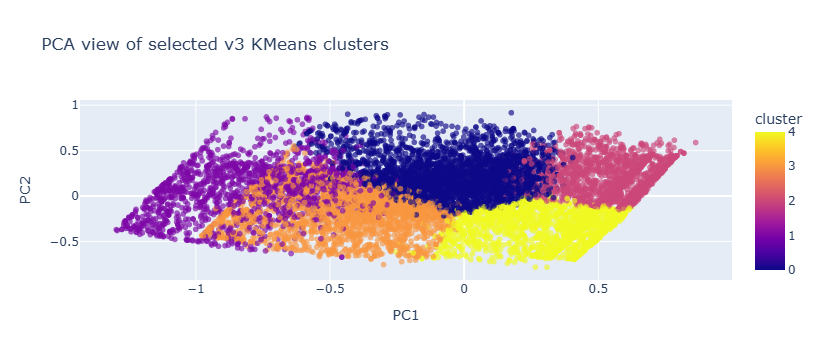

In [14]:
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color=BASELINE_CLUSTER_COL,
    title="PCA view of selected v3 KMeans clusters",
    opacity=0.65,
)
fig.show()

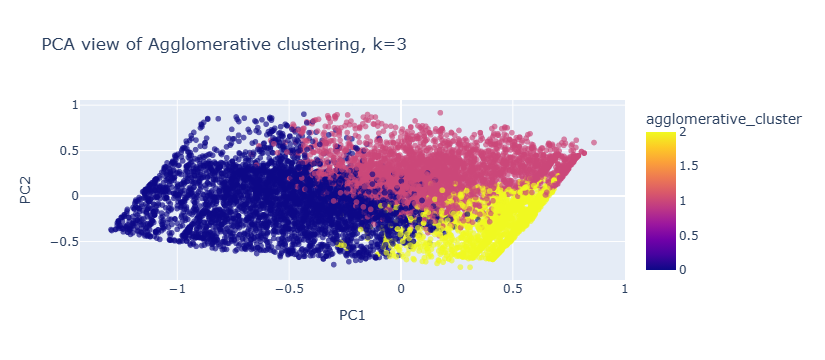

In [15]:
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="agglomerative_cluster",
    title=f"PCA view of Agglomerative clustering, k={best_agglo_k}",
    opacity=0.65,
)
fig.show()

In [16]:
if "dbscan_cluster" in pca_df.columns:
    fig = px.scatter(
        pca_df,
        x="PC1",
        y="PC2",
        color="dbscan_cluster",
        title=f"PCA view of DBSCAN, eps={best_dbscan_eps}, min_samples={best_dbscan_min_samples}",
        opacity=0.65,
    )
    fig.show()

## 13. Final method comparison

The selected method should not be based only on one metric. For this project, financial interpretability, stable five-level labelling, and private-company scoring compatibility matter more than maximizing a single unsupervised metric.

In [17]:
comparison_table = build_method_comparison_table(
    kmeans_metrics=kmeans_metrics,
    best_agglo_row=best_agglo_row,
    best_dbscan_row=best_dbscan_row,
)

display(comparison_table)

,method,selected_role,clusters,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans,comment
0,KMeans selected v3,Production model,5,0.263334,4862.604974,1.325291,1.000000,1.000000,Selected for stable five-level credit-risk lad...
1,Agglomerative best candidate,Robustness check,3,0.230730,4907.060542,1.378527,0.404253,0.499561,Useful hierarchy check; not selected because K...


## 14. Save alternative clustering outputs

In [18]:
agglo_results_sorted.to_csv(ALTERNATIVE_OUTPUT_DIR / "agglomerative_grid_results_v3.csv", index=False)
dbscan_results_sorted.to_csv(ALTERNATIVE_OUTPUT_DIR / "dbscan_grid_results_v3.csv", index=False)
comparison_table.to_csv(ALTERNATIVE_OUTPUT_DIR / "alternative_method_comparison_v3.csv", index=False)
agglo_profile.to_csv(ALTERNATIVE_OUTPUT_DIR / "agglomerative_profile_v3.csv", index=False)

if not dbscan_profile.empty:
    dbscan_profile.to_csv(ALTERNATIVE_OUTPUT_DIR / "dbscan_profile_v3.csv", index=False)

pca_df.to_csv(ALTERNATIVE_OUTPUT_DIR / "pca_projection_alternative_clustering_v3.csv", index=False)

print("Saved alternative clustering outputs to:", ALTERNATIVE_OUTPUT_DIR)

Saved alternative clustering outputs to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v3\alternative_clustering_v3


## 15. Conclusion template

Use this conclusion after reviewing the outputs:

> Agglomerative clustering and DBSCAN were tested as alternative unsupervised methods. Agglomerative clustering is useful as a hierarchical robustness check, while DBSCAN is useful as a density and outlier diagnostic. The selected KMeans model remains preferable for the production scorecard because it provides a stable five-level credit-risk ladder, centroid-based distance diagnostics, and direct compatibility with private-company scoring and PDF/Excel reporting.